In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import sys
sys.path.append('../analytics')

from engine import StockAnalytics

plt.rcParams['axes.facecolor']    = '#0f0f0f'
plt.rcParams['figure.facecolor']  = '#0f0f0f'
plt.rcParams['axes.edgecolor']    = '#333'
plt.rcParams['axes.labelcolor']   = '#999'
plt.rcParams['xtick.color']       = '#666'
plt.rcParams['ytick.color']       = '#666'
plt.rcParams['text.color']        = '#e5e5e5'
plt.rcParams['grid.color']        = '#1a1a1a'
plt.rcParams['grid.linestyle']    = '--'

print("Setup complete")

Setup complete


In [2]:
tickers = ['AAPL', 'MSFT', 'TSLA', 'INFY']
engines = {}

for ticker in tickers:
    s = StockAnalytics(ticker)
    s.run_all()
    engines[ticker] = s

print("All tickers loaded and analysed")
print("\nSignal summary:")
for ticker, s in engines.items():
    df = s.df
    buys  = len(df[df['signal'] == 'buy'])
    sells = len(df[df['signal'] == 'sell'])
    holds = len(df[df['signal'] == 'hold'])
    print(f"  {ticker}: {buys} buy | {sells} sell | {holds} hold")

Loaded 123 rows for AAPL
Loaded 123 rows for MSFT
Loaded 123 rows for TSLA
Loaded 123 rows for INFY
All tickers loaded and analysed

Signal summary:
  AAPL: 15 buy | 17 sell | 91 hold
  MSFT: 15 buy | 5 sell | 103 hold
  TSLA: 1 buy | 2 sell | 120 hold
  INFY: 10 buy | 0 sell | 113 hold


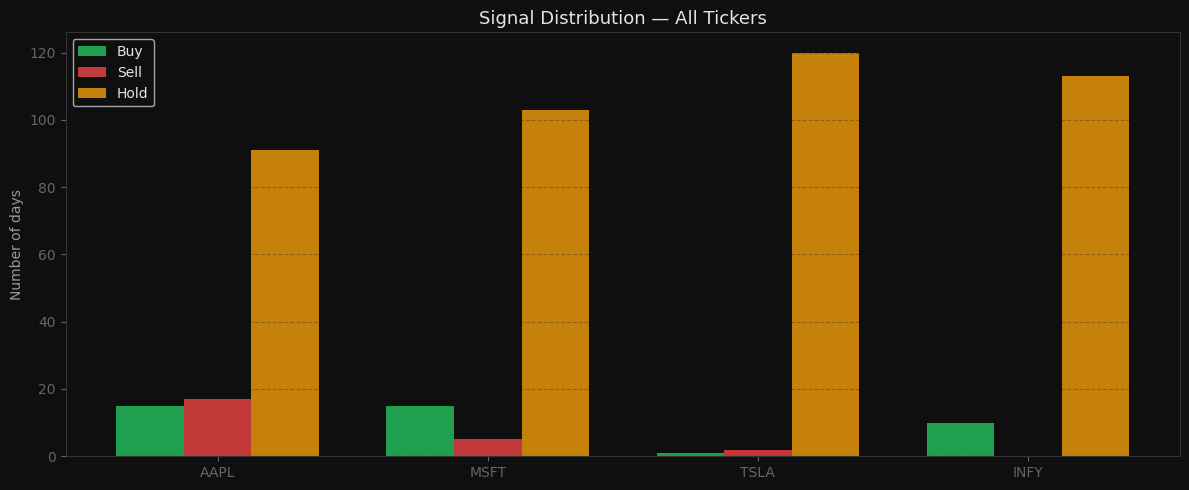

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

x       = np.arange(len(tickers))
width   = 0.25
colors  = {'buy': '#22c55e', 'sell': '#ef4444', 'hold': '#f59e0b'}

buy_counts  = [len(engines[t].df[engines[t].df['signal'] == 'buy'])  for t in tickers]
sell_counts = [len(engines[t].df[engines[t].df['signal'] == 'sell']) for t in tickers]
hold_counts = [len(engines[t].df[engines[t].df['signal'] == 'hold']) for t in tickers]

ax.bar(x - width, buy_counts,  width, color=colors['buy'],  alpha=0.8, label='Buy')
ax.bar(x,         sell_counts, width, color=colors['sell'], alpha=0.8, label='Sell')
ax.bar(x + width, hold_counts, width, color=colors['hold'], alpha=0.8, label='Hold')

ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_title('Signal Distribution — All Tickers', color='#e5e5e5', fontsize=13)
ax.set_ylabel('Number of days')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('signal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

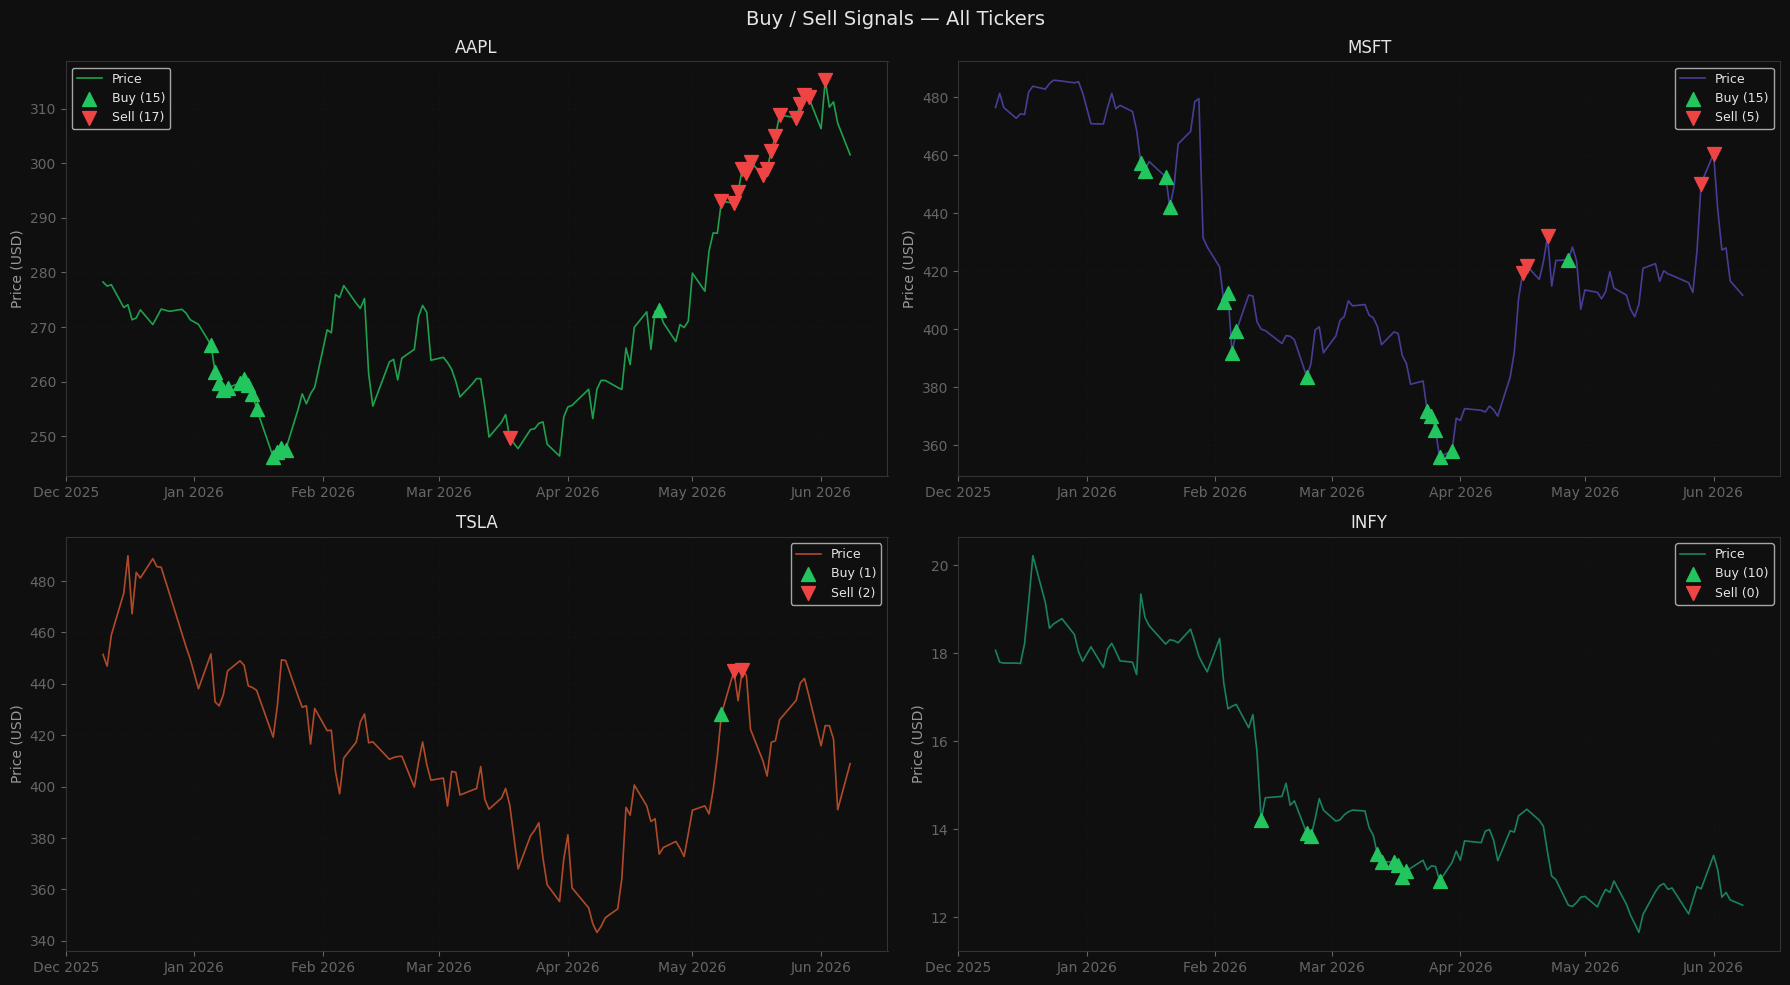

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Buy / Sell Signals — All Tickers', fontsize=14, color='#e5e5e5')
fig.patch.set_facecolor('#0f0f0f')

ticker_colors = ['#22c55e', '#534AB7', '#D85A30', '#1D9E75']

for ax, ticker, color in zip(axes.flatten(), tickers, ticker_colors):
    df = engines[ticker].df

    ax.set_facecolor('#0f0f0f')
    ax.plot(df['date'], df['close'], color=color, linewidth=1.2, alpha=0.8, label='Price')

    buys  = df[df['signal'] == 'buy']
    sells = df[df['signal'] == 'sell']

    ax.scatter(buys['date'],  buys['close'],
               color='#22c55e', marker='^', s=100, zorder=5, label=f'Buy ({len(buys)})')
    ax.scatter(sells['date'], sells['close'],
               color='#ef4444', marker='v', s=100, zorder=5, label=f'Sell ({len(sells)})')

    ax.set_title(ticker, color='#e5e5e5', fontsize=12)
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('all_signals.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:

print("=== Signal Performance Analysis ===\n")

for ticker in tickers:
    df = engines[ticker].df.copy().reset_index(drop=True)
    buy_indices = df[df['signal'] == 'buy'].index.tolist()

    results = []
    for idx in buy_indices:
        future_idx = idx + 10
        if future_idx < len(df):
            entry_price  = df.loc[idx,        'close']
            future_price = df.loc[future_idx, 'close']
            return_pct   = (future_price - entry_price) / entry_price * 100
            results.append({
                'date'        : str(df.loc[idx, 'date'].date()),
                'entry_price' : round(entry_price, 2),
                'price_10d'   : round(future_price, 2),
                'return_10d'  : round(return_pct, 2),
                'correct'     : return_pct > 0
            })

    if results:
        results_df  = pd.DataFrame(results)
        accuracy    = results_df['correct'].mean() * 100
        avg_return  = results_df['return_10d'].mean()

        print(f"{ticker}:")
        print(f"  Buy signals: {len(results)}")
        print(f"  Signal accuracy (price higher after 10 days): {accuracy:.1f}%")
        print(f"  Average 10-day return after buy signal: {avg_return:.2f}%")
        print(f"  Best signal:  {results_df.loc[results_df['return_10d'].idxmax(), 'date']} → {results_df['return_10d'].max():.2f}%")
        print(f"  Worst signal: {results_df.loc[results_df['return_10d'].idxmin(), 'date']} → {results_df['return_10d'].min():.2f}%")
        print()

=== Signal Performance Analysis ===

AAPL:
  Buy signals: 15
  Signal accuracy (price higher after 10 days): 46.7%
  Average 10-day return after buy signal: 1.90%
  Best signal:  2026-01-23 → 12.13%
  Worst signal: 2026-01-05 → -7.69%

MSFT:
  Buy signals: 15
  Signal accuracy (price higher after 10 days): 46.7%
  Average 10-day return after buy signal: -0.91%
  Best signal:  2026-03-30 → 9.51%
  Worst signal: 2026-01-20 → -9.53%

TSLA:
  Buy signals: 1
  Signal accuracy (price higher after 10 days): 0.0%
  Average 10-day return after buy signal: -0.55%
  Best signal:  2026-05-08 → -0.55%
  Worst signal: 2026-05-08 → -0.55%

INFY:
  Buy signals: 10
  Signal accuracy (price higher after 10 days): 70.0%
  Average 10-day return after buy signal: 2.07%
  Best signal:  2026-03-27 → 8.89%
  Worst signal: 2026-03-13 → -3.32%



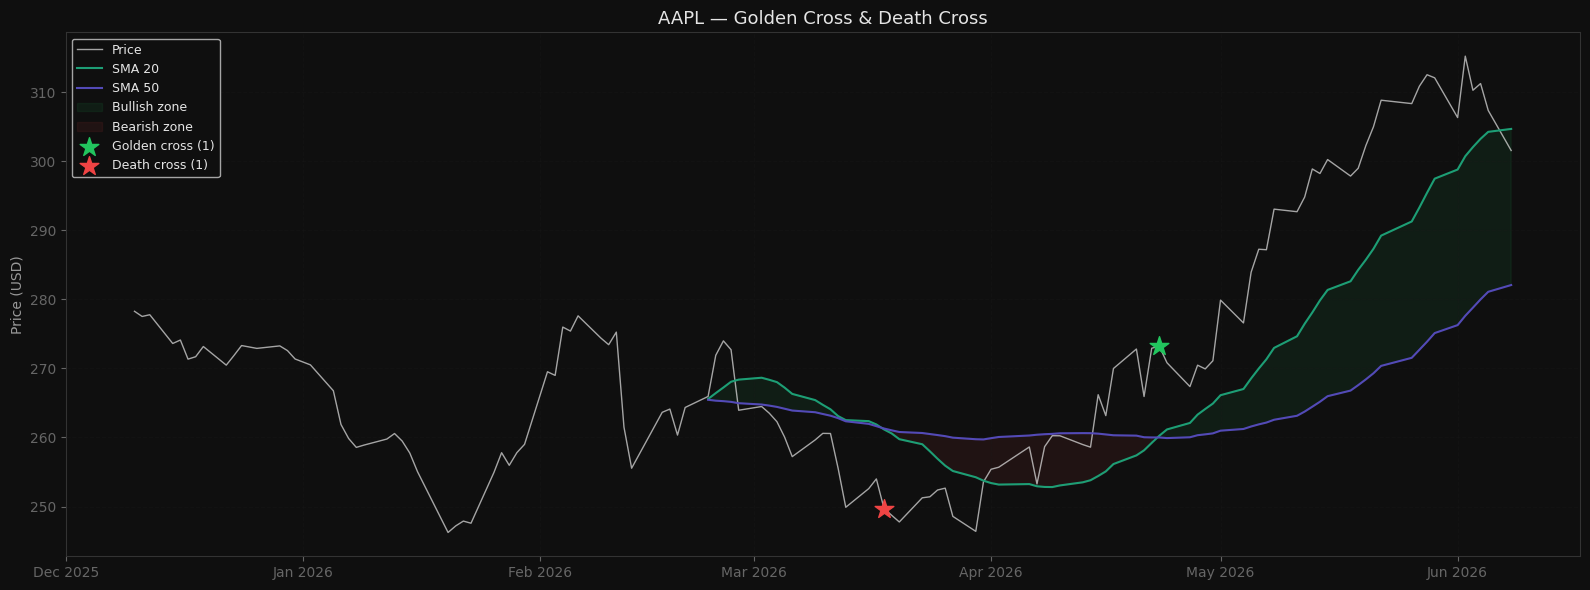

In [6]:
df = engines['AAPL'].df.copy()
df_ma = df.dropna(subset=['sma_20', 'sma_50'])

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(df['date'],    df['close'],  color='#e5e5e5', linewidth=1,   alpha=0.7, label='Price')
ax.plot(df_ma['date'], df_ma['sma_20'], color='#1D9E75', linewidth=1.5, label='SMA 20')
ax.plot(df_ma['date'], df_ma['sma_50'], color='#534AB7', linewidth=1.5, label='SMA 50')

ax.fill_between(df_ma['date'], df_ma['sma_20'], df_ma['sma_50'],
                where=df_ma['sma_20'] >= df_ma['sma_50'],
                color='#22c55e', alpha=0.08, label='Bullish zone')
ax.fill_between(df_ma['date'], df_ma['sma_20'], df_ma['sma_50'],
                where=df_ma['sma_20'] < df_ma['sma_50'],
                color='#ef4444', alpha=0.08, label='Bearish zone')

golden = df_ma[(df_ma['sma_20'] > df_ma['sma_50']) &
               (df_ma['sma_20'].shift(1) <= df_ma['sma_50'].shift(1))]
death  = df_ma[(df_ma['sma_20'] < df_ma['sma_50']) &
               (df_ma['sma_20'].shift(1) >= df_ma['sma_50'].shift(1))]

ax.scatter(golden['date'], golden['close'],
           color='#22c55e', marker='*', s=200, zorder=5, label=f'Golden cross ({len(golden)})')
ax.scatter(death['date'],  death['close'],
           color='#ef4444', marker='*', s=200, zorder=5, label=f'Death cross ({len(death)})')

ax.set_title('AAPL — Golden Cross & Death Cross', color='#e5e5e5', fontsize=13)
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('golden_death_cross.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
summary_rows = []

for ticker in tickers:
    s   = engines[ticker]
    df  = s.df
    stats = s.summary()

    summary_rows.append({
        'Ticker'         : ticker,
        'Total Return'   : f"{stats['total_return_pct']}%",
        'Sharpe Ratio'   : stats['sharpe_ratio'],
        'Max Drawdown'   : f"{stats['max_drawdown_pct']}%",
        'Annual Vol'     : f"{stats['annual_vol_pct']}%",
        'Current RSI'    : stats['rsi_current'],
        'Current Signal' : stats['signal_current'].upper(),
        'Buy Signals'    : len(df[df['signal'] == 'buy']),
        'Sell Signals'   : len(df[df['signal'] == 'sell']),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Ticker')
print("=== Complete Analytics Summary ===")
summary_df

=== Complete Analytics Summary ===


,Total Return,Sharpe Ratio,Max Drawdown,Annual Vol,Current RSI,Current Signal,Buy Signals,Sell Signals
Ticker,,,,,,,,
AAPL,10.63%,1.06,-11.35%,19.06%,53.4,HOLD,15,17
MSFT,-15.16%,-0.97,-26.73%,36.32%,45.5,HOLD,15,5
TSLA,-10.01%,-0.47,-29.93%,48.06%,48.0,HOLD,1,2
INFY,-31.93%,-1.98,-42.33%,46.35%,44.6,HOLD,10,0
